In [1]:
import requests
import pandas as pd
from datetime import date, timedelta

yesterday = (date.today() - timedelta(days=1)).strftime("%Y-%m-%d")

url = (
    "https://archive-api.open-meteo.com/v1/archive?"
    "latitude=21.63&longitude=88.17"
    "&start_date=2020-01-01"
    "&end_date={}"
    "&hourly=temperature_2m,"
    "windspeed_10m,"
    "surface_pressure,"
    "cloudcover,"
    "rain,"
    "shortwave_radiation"
    "&timezone=Asia/Kolkata".format(yesterday)
)


response = requests.get(url)
data = response.json()

df = pd.DataFrame(data["hourly"])

# Rename columns (clean dataset)
df = df.rename(columns={
    "temperature_2m": "Temperature(C)",
    "windspeed_10m": "Wind_Speed(m/s)",
    "surface_pressure": "Pressure(hPa)",
    "cloudcover": "Cloud_Coverage(%)",
    "rain": "Rain(mm/hour)",
    "shortwave_radiation": "Solar_Radiation(W/m^2)"
})

print(df.head())
print("Saved successfully!")


C:\Users\prasu\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\prasu\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


               time  Temperature(C)  Wind_Speed(m/s)  Pressure(hPa)  \
0  2020-01-01T00:00            16.9              7.7         1017.8   
1  2020-01-01T01:00            17.4              7.8         1017.5   
2  2020-01-01T02:00            17.6              7.0         1017.3   
3  2020-01-01T03:00            14.8              9.5         1017.2   
4  2020-01-01T04:00            14.0              9.7         1017.2   

   Cloud_Coverage(%)  Rain(mm/hour)  Solar_Radiation(W/m^2)  
0                  1            0.0                     0.0  
1                  1            0.0                     0.0  
2                  1            0.0                     0.0  
3                  3            0.0                     0.0  
4                  4            0.0                     0.0  
Saved successfully!


In [2]:
df

,time,Temperature(C),Wind_Speed(m/s),Pressure(hPa),Cloud_Coverage(%),Rain(mm/hour),Solar_Radiation(W/m^2)
0,2020-01-01T00:00,16.9,7.7,1017.8,1,0.0,0.0
1,2020-01-01T01:00,17.4,7.8,1017.5,1,0.0,0.0
2,2020-01-01T02:00,17.6,7.0,1017.3,1,0.0,0.0
3,2020-01-01T03:00,14.8,9.5,1017.2,3,0.0,0.0
4,2020-01-01T04:00,14.0,9.7,1017.2,4,0.0,0.0
...,...,...,...,...,...,...,...
54091,2026-03-03T19:00,24.8,6.2,1011.0,0,0.0,0.0
54092,2026-03-03T20:00,24.2,5.0,1011.7,0,0.0,0.0
54093,2026-03-03T21:00,24.0,1.9,1012.4,0,0.0,0.0
54094,2026-03-03T22:00,23.7,0.9,1012.5,0,0.0,0.0


In [3]:
import requests
import pandas as pd

url = (
    "https://archive-api.open-meteo.com/v1/archive?"
    "latitude=21.63&longitude=88.17"
    "&start_date=2019-01-01"
    "&end_date={}"
    "&hourly=temperature_2m,relativehumidity_2m,precipitation,windspeed_10m"
    "&timezone=Asia/Kolkata".format(yesterday)
)

response = requests.get(url)
data = response.json()

df1 = pd.DataFrame(data["hourly"])
print("Saved successfully!")


Saved successfully!


In [4]:
df1

,time,temperature_2m,relativehumidity_2m,precipitation,windspeed_10m
0,2019-01-01T00:00,14.2,88,0.0,10.1
1,2019-01-01T01:00,13.8,89,0.0,10.9
2,2019-01-01T02:00,14.1,88,0.0,8.3
3,2019-01-01T03:00,13.9,89,0.0,7.6
4,2019-01-01T04:00,13.4,91,0.0,7.2
...,...,...,...,...,...
62467,2026-02-15T19:00,21.3,94,0.0,4.8
62468,2026-02-15T20:00,20.9,94,0.0,3.0
62469,2026-02-15T21:00,20.6,94,0.0,1.8
62470,2026-02-15T22:00,20.2,95,0.0,2.0


In [5]:
df['Relative_Humidity(%)'] = df1['relativehumidity_2m']

In [6]:
df

,time,Temperature(C),Wind_Speed(m/s),Pressure(hPa),Cloud_Coverage(%),Rain(mm/hour),Solar_Radiation(W/m^2),Relative_Humidity(%)
0,2020-01-01T00:00,16.9,7.7,1017.8,1,0.0,0.0,88
1,2020-01-01T01:00,17.4,7.8,1017.5,1,0.0,0.0,89
2,2020-01-01T02:00,17.6,7.0,1017.3,1,0.0,0.0,88
3,2020-01-01T03:00,14.8,9.5,1017.2,3,0.0,0.0,89
4,2020-01-01T04:00,14.0,9.7,1017.2,4,0.0,0.0,91
...,...,...,...,...,...,...,...,...
54091,2026-03-03T19:00,24.8,6.2,1011.0,0,0.0,0.0,94
54092,2026-03-03T20:00,24.2,5.0,1011.7,0,0.0,0.0,94
54093,2026-03-03T21:00,24.0,1.9,1012.4,0,0.0,0.0,95
54094,2026-03-03T22:00,23.7,0.9,1012.5,0,0.0,0.0,95


In [7]:
import seaborn as sns

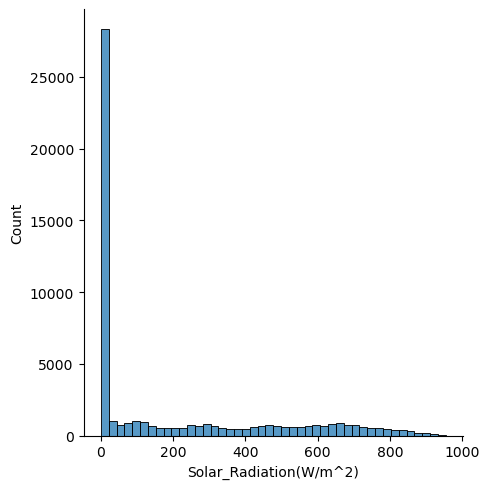

In [8]:
sns.displot(df['Solar_Radiation(W/m^2)'])

In [9]:
df[df['Solar_Radiation(W/m^2)'] == 0 ]

,time,Temperature(C),Wind_Speed(m/s),Pressure(hPa),Cloud_Coverage(%),Rain(mm/hour),Solar_Radiation(W/m^2),Relative_Humidity(%)
0,2020-01-01T00:00,16.9,7.7,1017.8,1,0.0,0.0,88
1,2020-01-01T01:00,17.4,7.8,1017.5,1,0.0,0.0,89
2,2020-01-01T02:00,17.6,7.0,1017.3,1,0.0,0.0,88
3,2020-01-01T03:00,14.8,9.5,1017.2,3,0.0,0.0,89
4,2020-01-01T04:00,14.0,9.7,1017.2,4,0.0,0.0,91
...,...,...,...,...,...,...,...,...
54091,2026-03-03T19:00,24.8,6.2,1011.0,0,0.0,0.0,94
54092,2026-03-03T20:00,24.2,5.0,1011.7,0,0.0,0.0,94
54093,2026-03-03T21:00,24.0,1.9,1012.4,0,0.0,0.0,95
54094,2026-03-03T22:00,23.7,0.9,1012.5,0,0.0,0.0,95


In [10]:
df['Pressure(hPa)'] = df['Pressure(hPa)']/10

In [11]:
df.rename(columns={'Pressure(hPa)':'Pressure(kPa'}, inplace=True)

In [12]:
df

,time,Temperature(C),Wind_Speed(m/s),Pressure(kPa,Cloud_Coverage(%),Rain(mm/hour),Solar_Radiation(W/m^2),Relative_Humidity(%)
0,2020-01-01T00:00,16.9,7.7,101.78,1,0.0,0.0,88
1,2020-01-01T01:00,17.4,7.8,101.75,1,0.0,0.0,89
2,2020-01-01T02:00,17.6,7.0,101.73,1,0.0,0.0,88
3,2020-01-01T03:00,14.8,9.5,101.72,3,0.0,0.0,89
4,2020-01-01T04:00,14.0,9.7,101.72,4,0.0,0.0,91
...,...,...,...,...,...,...,...,...
54091,2026-03-03T19:00,24.8,6.2,101.10,0,0.0,0.0,94
54092,2026-03-03T20:00,24.2,5.0,101.17,0,0.0,0.0,94
54093,2026-03-03T21:00,24.0,1.9,101.24,0,0.0,0.0,95
54094,2026-03-03T22:00,23.7,0.9,101.25,0,0.0,0.0,95


In [13]:
df.to_csv("Dataset.csv")

In [14]:
# convert to datetime
df['time'] = pd.to_datetime(df['time'])

# create separate columns
df['year']  = df['time'].dt.year
df['month'] = df['time'].dt.month
df['day']   = df['time'].dt.day
df['hour']  = df['time'].dt.hour

# (optional) drop original column
# df.drop(columns=['time'], inplace=True)

df.head()


,time,Temperature(C),Wind_Speed(m/s),Pressure(kPa,Cloud_Coverage(%),Rain(mm/hour),Solar_Radiation(W/m^2),Relative_Humidity(%),year,month,day,hour
0,2020-01-01 00:00:00,16.9,7.7,101.78,1,0.0,0.0,88,2020,1,1,0
1,2020-01-01 01:00:00,17.4,7.8,101.75,1,0.0,0.0,89,2020,1,1,1
2,2020-01-01 02:00:00,17.6,7.0,101.73,1,0.0,0.0,88,2020,1,1,2
3,2020-01-01 03:00:00,14.8,9.5,101.72,3,0.0,0.0,89,2020,1,1,3
4,2020-01-01 04:00:00,14.0,9.7,101.72,4,0.0,0.0,91,2020,1,1,4


In [15]:
df.rename(columns={'time':'Datetime', "Temperature(C)": "Temperature(°C)"}, inplace=True)

In [16]:
col = df.pop('day')
df.insert(2, 'day', col)   

In [17]:
col = df.pop('month')
df.insert(3, 'month', col)   

In [18]:
col = df.pop('year')
df.insert(4, 'year', col)   

In [19]:
col = df.pop('hour')
df.insert(5, 'hour', col)   

In [20]:
df["wind_lag1"] = df["Wind_Speed(m/s)"].shift(1)
df["wind_lag3"] = df["Wind_Speed(m/s)"].shift(3)
df["wind_lag24"] = df["Wind_Speed(m/s)"].shift(24)

In [21]:
col = df.pop('hour')
df.insert(1, 'hour', col)   

In [22]:
col = df.pop('Temperature(°C)')
df.insert(7, 'Temperature(°C)', col)   

In [23]:
col = df.pop('Wind_Speed(m/s)')
df.insert(6, 'Wind_Speed(m/s)', col)   

In [24]:
df.rename(columns={'Solar_Radiation(W/m^2)':'Radiation(W/m^2)'},inplace=True)


In [25]:
col = df.pop('Cloud_Coverage(%)')
df.insert(9, 'Cloud_Coverage(%)', col)   

In [26]:
col = df.pop('Radiation(W/m^2)')
df.insert(8, 'Radiation(W/m^2)', col)   

In [27]:
col = df.pop('Cloud_Coverage(%)')
df.insert(9, 'Cloud_Coverage(%)', col)   

In [28]:
col = df.pop('Relative_Humidity(%)')
df.insert(11, 'Relative_Humidity(%)', col)   

In [29]:
df

,Datetime,hour,day,month,year,Pressure(kPa,Wind_Speed(m/s),Temperature(°C),Radiation(W/m^2),Cloud_Coverage(%),Rain(mm/hour),Relative_Humidity(%),wind_lag1,wind_lag3,wind_lag24
0,2020-01-01 00:00:00,0,1,1,2020,101.78,7.7,16.9,0.0,1,0.0,88,NaN,NaN,NaN
1,2020-01-01 01:00:00,1,1,1,2020,101.75,7.8,17.4,0.0,1,0.0,89,7.7,NaN,NaN
2,2020-01-01 02:00:00,2,1,1,2020,101.73,7.0,17.6,0.0,1,0.0,88,7.8,NaN,NaN
3,2020-01-01 03:00:00,3,1,1,2020,101.72,9.5,14.8,0.0,3,0.0,89,7.0,7.7,NaN
4,2020-01-01 04:00:00,4,1,1,2020,101.72,9.7,14.0,0.0,4,0.0,91,9.5,7.8,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54091,2026-03-03 19:00:00,19,3,3,2026,101.10,6.2,24.8,0.0,0,0.0,94,8.6,10.2,7.5
54092,2026-03-03 20:00:00,20,3,3,2026,101.17,5.0,24.2,0.0,0,0.0,94,6.2,7.2,7.3
54093,2026-03-03 21:00:00,21,3,3,2026,101.24,1.9,24.0,0.0,0,0.0,95,5.0,8.6,2.4
54094,2026-03-03 22:00:00,22,3,3,2026,101.25,0.9,23.7,0.0,0,0.0,95,1.9,6.2,4.3


In [30]:
df.to_json("{}.json".format(yesterday))

C:\Users\prasu\AppData\Local\Temp\ipykernel_3060\675072559.py:1: Pandas4Warning: The default 'epoch' date format is deprecated and will be removed in a future version, please use 'iso' date format instead.
  df.to_json("{}.json".format(yesterday))


In [31]:
df.to_csv("{}.csv".format(yesterday))